# Entrenamiento del modelo FINANOM — apoyo al auditor nocturno

Modelo **híbrido**: Isolation Forest (no supervisado) + **reglas de negocio tipadas**. Produce un **reporte de revisión explicable** que el auditor nocturno puede fundir con su informe de transacciones del PMS.

El pipeline reproducible vive en [`train_model.py`](train_model.py); este notebook documenta las decisiones, visualiza resultados y resume la evaluación recursiva.

## 1. Información del negocio → decisiones de modelado

De las entrevistas con el hotel:

| Necesidad del negocio | Decisión en el modelo |
| --- | --- |
| Apoyo al auditor nocturno, reducir tiempo | Cola priorizada de ~2% (presupuesto revisable) |
| Resaltar inconsistencias en su reporte | Salida con columnas `trace_*` + score + flags, fusionable |
| Errores identificados de antemano | Explicabilidad: `motivos` + `top_features` por alerta |
| Seleccionar correcciones con aprobación | `accion_sugerida` + `requiere_aprobacion` (human-in-the-loop) |
| Modificaciones no autorizadas | regla `modificacion_no_autorizada` |
| Facturas/reemplazos con monto incorrecto | reglas `monto_atipico` y `reemplazo_monto` |
| Métodos de pago mal usados (Visa↔Amex) | regla `metodo_pago_inconsistente` (Amex vs tarjeta genérica) |
| Cargos duplicados | regla `posible_duplicado` |

`signo_contable` se **descartó** como regla: en este PMS el abono-positivo es la convención normal y el cargo-negativo son reversos legítimos.

In [1]:
from pathlib import Path
import sys, json
import numpy as np, pandas as pd

p = Path.cwd()
ROOT = next((x for x in [p, *p.parents] if (x / 'pyproject.toml').exists()), p)
sys.path.insert(0, str(ROOT))
from model_training import train_model as tm  # fija backend Agg

# Restaurar backend inline (train_model forzo Agg para correr headless)
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt

paths = tm.TrainingPaths.from_dir()
if not paths.report_parquet.exists():
    tm.run_training()  # genera artefactos si no existen (idempotente)

report = pd.read_parquet(paths.report_parquet)
diag = json.loads(paths.eval_json_file.read_text(encoding='utf-8'))
print('Reporte:', report.shape, '| marcadas:', int(report['is_anomaly'].sum()))

Reporte: (1145526, 25) | marcadas: 23429


## 2. El modelo híbrido

- **Isolation Forest** sobre las 63 features `feat_*` (entrenado en el 80% temporal más antiguo). Da un `anomaly_score` continuo y capta atípicos *multidimensionales desconocidos*.
- **Reglas tipadas** sobre features + campos crudos: cubren las inconsistencias que el hotel nombró, cada una con su razón legible.
- **Cola de revisión** = IF top-1% ∪ reglas críticas (todas) ∪ reglas amplias (top-K por score).

In [2]:
m = report[report['is_anomaly']]
print(f'Cola de revisión: {len(m):,} ({100*len(m)/len(report):.2f}% de la base)')
m['tipo_inconsistencia'].value_counts().head(10)

Cola de revisión: 23,429 (2.05% de la base)


tipo_inconsistencia
monto_atipico                                               8350
atipico_general                                             5822
posible_duplicado                                           4482
cargo_fuera_estancia                                        1761
modificacion_no_autorizada                                   918
monto_atipico,modificacion_no_autorizada                     686
modificacion_no_autorizada,cargo_fuera_estancia              566
monto_atipico,cargo_fuera_estancia                           214
reemplazo_monto,modificacion_no_autorizada                   190
monto_atipico,reemplazo_monto,modificacion_no_autorizada     137
Name: count, dtype: int64

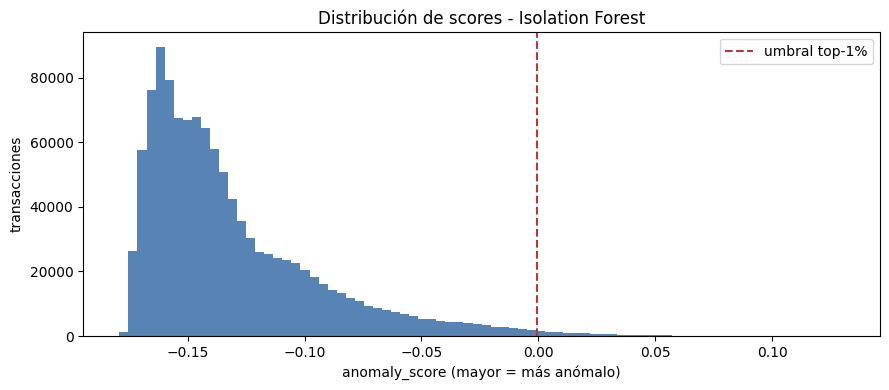

In [3]:
plt.figure(figsize=(9, 4))
plt.hist(report['anomaly_score'], bins=80, color='#3b6ea8', alpha=0.85)
plt.axvline(diag['threshold'], color='#b23b3b', ls='--', label='umbral top-1%')
plt.xlabel('anomaly_score (mayor = más anómalo)'); plt.ylabel('transacciones')
plt.title('Distribución de scores - Isolation Forest'); plt.legend(); plt.tight_layout(); plt.show()

## 3. Anomalías priorizadas con su explicación

Cada alerta trae el tipo de inconsistencia, el motivo legible, las features que la aislaron y la acción sugerida — lista para que el auditor revise y apruebe.

In [4]:
cols = ['trace_t_folio', 'trace_t_codigo', 'trace_t_timestamp', 'anomaly_score',
        'tipo_inconsistencia', 'motivos', 'accion_sugerida']
m.sort_values('anomaly_score', ascending=False).head(10)[cols]

,trace_t_folio,trace_t_codigo,trace_t_timestamp,anomaly_score,tipo_inconsistencia,motivos,accion_sugerida
557641,45001,RENAJU,2023-02-11 10:24:00,0.130645,"monto_atipico,cargo_fuera_estancia",Monto muy fuera de rango para su concepto (z=1...,Revisar el monto contra la tarifa/concepto esp...
557640,45001,RENAJU,2023-02-11 10:23:00,0.130645,"monto_atipico,cargo_fuera_estancia",Monto muy fuera de rango para su concepto (z=1...,Revisar el monto contra la tarifa/concepto esp...
557639,45001,RENAJU,2023-02-11 10:20:00,0.128985,"monto_atipico,cargo_fuera_estancia",Monto muy fuera de rango para su concepto (z=1...,Revisar el monto contra la tarifa/concepto esp...
228797,17256,TRANSF,2021-12-08 12:59:00,0.127057,modificacion_no_autorizada,Modificada por un usuario distinto y coincide ...,Validar la autorizacion de la modificacion.
919611,90313,RENAJU,2024-04-26 15:04:00,0.126663,"monto_atipico,modificacion_no_autorizada,cargo...",Monto muy fuera de rango para su concepto (z=1...,Revisar el monto contra la tarifa/concepto esp...
948619,90455,RENAJU,2024-04-24 12:06:00,0.123607,"monto_atipico,cargo_fuera_estancia",Monto muy fuera de rango para su concepto (z=1...,Revisar el monto contra la tarifa/concepto esp...
25633,352,CANCXC,2021-03-12 15:43:00,0.120963,"modificacion_no_autorizada,cargo_fuera_estancia",Modificada por un usuario distinto y coincide ...,Validar la autorizacion de la modificacion.
557644,45001,RENAJU,2023-02-11 10:28:00,0.120018,cargo_fuera_estancia,Cargo fechado fuera de la ventana de estancia ...,Verificar la fecha del cargo contra la estancia.
557642,45001,RENAJU,2023-02-11 10:26:00,0.118068,cargo_fuera_estancia,Cargo fechado fuera de la ventana de estancia ...,Verificar la fecha del cargo contra la estancia.
875236,143649,RENAJU,2026-01-13 16:36:00,0.117952,cargo_fuera_estancia,Cargo fechado fuera de la ventana de estancia ...,Verificar la fecha del cargo contra la estancia.


## 4. Evaluación recursiva (sin etiquetas)

### Inyección sintética: IF solo vs híbrido
Se inyectan anomalías conocidas en filas normales y se mide cuántas marca el sistema. **Hallazgo**: el IF global subpondera anomalías extremas en pocas dimensiones (*swamping* entre 63 features), por eso su recall es bajo; las reglas las capturan, así que el híbrido se acerca al 100%. Esto justifica la arquitectura híbrida.

In [5]:
inj = diag['injection_recall']
pd.DataFrame({k: {'IF solo': v['if'], 'Híbrido': v['hibrido']} for k, v in inj.items()}).T

,IF solo,Híbrido
monto_inflado,0.0,1.0
duplicado_extremo,0.0,1.0
cargo_fuera_estancia,0.0,1.0
modificacion_con_monto,0.0,1.0
promedio,0.0,1.0


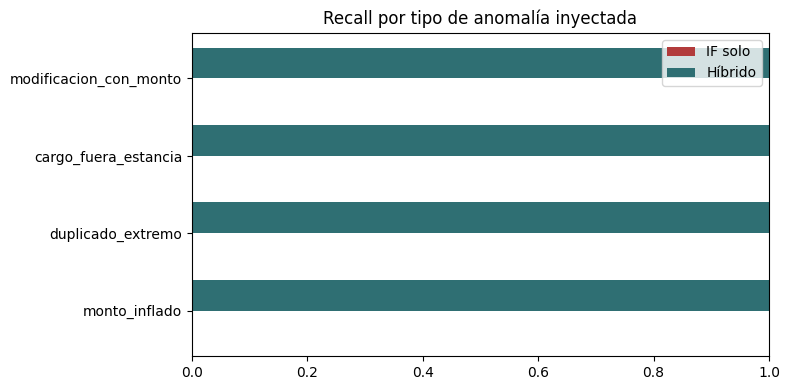

In [6]:
inj = diag['injection_recall']
types = [k for k in inj if k != 'promedio']
y = np.arange(len(types))
plt.figure(figsize=(8, 4))
plt.barh(y - 0.2, [inj[k]['if'] for k in types], height=0.4, color='#b23b3b', label='IF solo')
plt.barh(y + 0.2, [inj[k]['hibrido'] for k in types], height=0.4, color='#2f6f73', label='Híbrido')
plt.yticks(y, types); plt.xlim(0, 1); plt.legend()
plt.title('Recall por tipo de anomalía inyectada'); plt.tight_layout(); plt.show()

### Overlap IF ↔ reglas y estabilidad temporal

El IF y las reglas son casi **disjuntos**: cada capa aporta alertas que la otra no ve (el IF, atípicos sin regla; las reglas, los tipos críticos que el IF subpondera). La tasa de marcado es estable entre el periodo de entrenamiento y el reciente.

In [7]:
ov = diag['overlap']
print('Overlap IF vs reglas críticas:')
for k, v in ov.items():
    print(f'  {k}: {v:,}')
print('\nEstabilidad temporal (tasa de marcado por periodo):')
for per, s in diag['stability'].items():
    print(f'  {per}: {s["tasa_marcado"]:.2%}')

Overlap IF vs reglas críticas:
  if_top: 11,518
  reglas_criticas: 14,002
  interseccion: 2,091
  solo_reglas_criticas: 11,911
  solo_if: 9,427

Estabilidad temporal (tasa de marcado por periodo):
  entrenamiento: 1.00%
  reciente: 1.03%


## 5. Bucle de feedback del auditor (diseño + stub)

Cada revisión del auditor (accept/reject) se anexa a `output/feedback_labels.csv` (`trace_row_id`, `decision`, `revisor`, `timestamp_revision`, `nota`).

`apply_feedback()` ya mide la precisión observada y sugiere ajustar el umbral. El **re-ranker supervisado** (entrenar un clasificador sobre las etiquetas acumuladas para reordenar las candidatas del IF) queda diseñado como TODO: el enganche está listo, no se implementa la simulación en esta fase.

In [8]:
labels = pd.read_csv(paths.labels_store_file)
tm.apply_feedback(report, labels, diag['threshold'])

{'estado': 'sin_etiquetas',
 'umbral_actual': -0.0005665424264419995,
 'nota': 'Aun no hay revisiones del auditor; el modelo opera con el umbral base.'}

## 6. Limitaciones y siguientes pasos

- **No supervisado**: sin etiquetas reales; calidad validada por inyección/inspección.
- **Pago**: Amex (`AMEXCO`) es separable; Visa vs Mastercard no (ambos `TARCRE`).
- **Sin datos de factura** (vacíos en MX): 'factura incorrecta' se aproxima vía monto/reemplazo.
- **Scoring intra-día**: requiere pasar las transacciones nuevas por el pipeline de datos (consolidación → limpieza → modelado) para obtener las `feat_*`; persistir los transformadores de FE para streaming puro es un paso siguiente.
- **Siguiente**: implementar el re-ranker supervisado del bucle de feedback y exponer el reporte en la plataforma del auditor.